In [7]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) return false;

<IPython.core.display.Javascript object>

In [8]:
import dataset, plots, features
import pandas as pd
import yfinance as yf

sp500_components = dataset.SP500.load_historical()

## Dane cenowe

Do selekcji spółek do portfela z wykorzystaniem analizy technicznej w dłuższym terminie wystarczają wartości uzyskane pod koniec sesji każdego dnia (**End-of-Day, EOD**). Ponieważ dane muszą obejmować również spółki, które już nie istnieją, aby uniknąć błędów badawczych, darmowe źródła często okazują się niewystarczające. W praktyce można przyjąć dwa podejścia:

- pobranie danych cenowych z darmowych źródeł i uzupełnienie brakujących danych profesjonalnym dostawcą

- pobranie wszystkich danych bezpośrednio od profesjonalnego dostawcy.

W tym projekcie wybrane zostało pierwsze podejście, aby zwizualizować potencjalny wpływ brakujących lub niekompletnych danych na wyniki analizy.

### Dane cenowe z Yahoo Finance

Najpopularniejszą opcją pozyskania danych cenowych jest korzystanie z [**Yahoo Finance**](https://finance.yahoo.com/?guccounter=1), np. poprzez bibliotekę [**yfinance**](https://github.com/ranaroussi/yfinance) w Pythonie, która umożliwia pobranie danych historycznych spółek wraz z cenami skorygowanymi o splity i dywidendy.

#### Uzyskanie danych z pojedynczej spółki

Poniżej przykładowe użycie tej biblioteki w celu uzyskania historii cen akcji spółki Apple (AAPL). Dane cenowe zamknięcia (**Adj Close**) są już skorygowane o dywidendy.

In [9]:
ticker = "AAPL"
apple = yf.download(ticker, period="max", actions=True, auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [10]:
plots.summarize_df(apple)

DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 11458 entries, 1980-12-12 to 2026-06-01
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   (Adj Close, AAPL)     11458 non-null  float64
 1   (Close, AAPL)         11458 non-null  float64
 2   (Dividends, AAPL)     11458 non-null  float64
 3   (High, AAPL)          11458 non-null  float64
 4   (Low, AAPL)           11458 non-null  float64
 5   (Open, AAPL)          11458 non-null  float64
 6   (Stock Splits, AAPL)  11458 non-null  float64
 7   (Volume, AAPL)        11458 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 805.6 KB
None


Price,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,11458.00000000,11458.00000000,11458.00000000,11458.00000000,11458.00000000,11458.00000000,11458.00000000,11458.00000000
mean,30.07687869,31.05297590,0.00090186,31.36416122,30.71336463,31.02791995,0.00148368,307369895.09643918
std,61.80393574,62.36661705,0.01336594,62.97466707,61.69629963,62.30379061,0.08196695,332831224.83012748
min,0.03757482,0.04910700,0.00000000,0.04966500,0.04910700,0.04966500,0.00000000,0.00000000
25%,0.24794810,0.30580401,0.00000000,0.31250000,0.29910699,0.30580401,0.00000000,104771800.00000000
50%,0.51616624,0.62818047,0.00000000,0.63948652,0.61383897,0.62500000,0.00000000,196526000.00000000
75%,22.20838594,24.91062546,0.00000000,25.11687517,24.63812494,24.83062553,0.00000000,387363200.00000000
max,312.51000977,312.51000977,0.27000000,315.00000000,309.57000732,311.77999878,7.00000000,7421640800.00000000


Price,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,,,
1980-12-12,0.09820702,0.12834799,0.00000000,0.12890600,0.12834799,0.12834799,0.00000000,469033600
1980-12-15,0.09308352,0.12165200,0.00000000,0.12221000,0.12165200,0.12221000,0.00000000,175884800
2026-05-29,312.05999756,312.05999756,0.00000000,315.00000000,309.52999878,311.77999878,0.00000000,69982800
2026-06-01,307.89498901,307.89498901,0.00000000,310.92999268,305.02999878,309.53500366,0.00000000,30025315


Poniższy fragment danych — dzień przed, w dniu oraz dzień po splicie akcji — pokazuje, że ceny w danych historycznych uwzględniają już split.

In [11]:
plots.YahooFinance.show_last_split(apple)

Price,Open,Adj Close,Dividends,Stock Splits
Date,,,,
2020-08-28,126.01249695,121.05998993,0.00000000,0.00000000
2020-08-31,127.58000183,125.16539001,0.00000000,4.00000000
2020-09-01,132.75999451,130.15104675,0.00000000,0.00000000


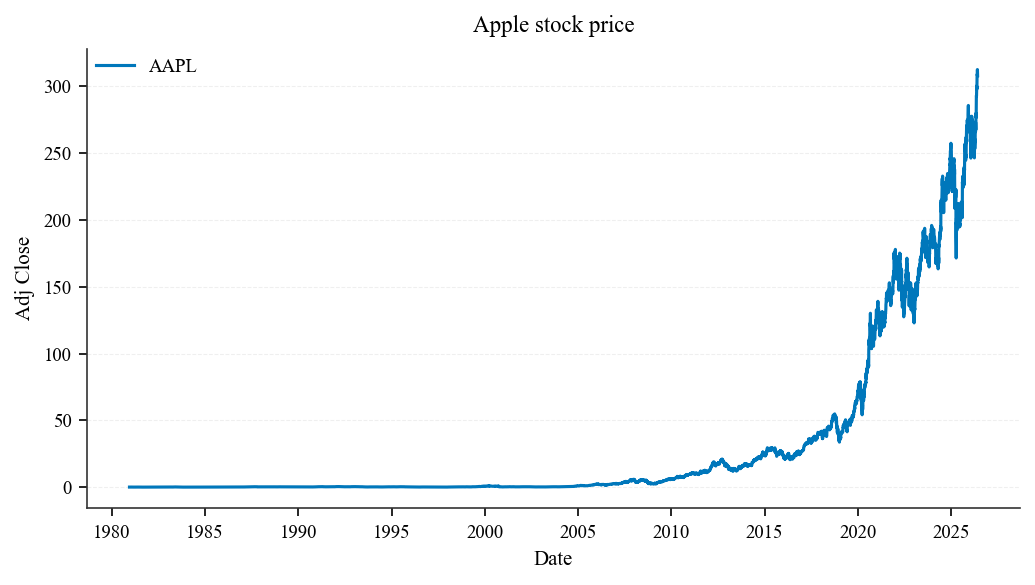

,AAPL
Date,
1980-12-12,0.09820702
1980-12-15,0.09308352
1980-12-16,0.08625136
1980-12-17,0.08838619
1980-12-18,0.09094870
...,...
2026-05-26,308.32998657
2026-05-27,310.85000610
2026-05-28,312.51000977


In [12]:
plots.YahooFinance.show_chart(
    df=apple,
    label=ticker,
    title="Apple stock price",
    hide_col=True,
    filename="10-apple-stock-price.png",
)

#### Uzyskanie danych o indeksie

Na platformie Yahoo Finance dostępne są różne tickery reprezentujące indeks S&P 500, które różnią się sposobem uwzględniania dywidend:

- **SP500 (^GSPC, S&P 500)** – indeks cenowy (*price return*), uwzględniający wyłącznie zmiany cen akcji spółek wchodzących w skład indeksu
- **SP500TR (^SP500TR, S&P 500 Total Return)** – indeks dochodowy (*total return*), uwzględniający zarówno zmiany cen, jak i reinwestowane dywidendy
- **ETF (CSPX.L, iShares Core S&P 500 UCITS ETF Acc)** – fundusz ETF replikujący indeks S&P 500 w sposób fizyczny, akumulujący dywidendy (reinwestowane wewnątrz funduszu), stanowiący przybliżenie rzeczywistej stopy zwrotu inwestora

Zestawienie tych trzech instrumentów pozwala porównać:
- wpływ dywidend na długoterminową stopę zwrotu,
- różnice między indeksem teoretycznym a rzeczywistym instrumentem inwestycyjnym,
- dokładność odwzorowania indeksu przez ETF (tzw. *tracking error*).

In [13]:
tickers = ["^GSPC", "^SP500TR", "CSPX.L", "^SP500EW", "RSP"]

In [14]:
dataset.YahooFinance.download(tickers)


2 Failed downloads:
['RSP', '^SP500TR']: TypeError("'NoneType' object is not subscriptable")


Saved Close.csv (24809 rows x 1199 columns)
Saved Open.csv (24809 rows x 1199 columns)
Saved High.csv (24809 rows x 1199 columns)
Saved Low.csv (24809 rows x 1199 columns)
Saved Volume.csv (24809 rows x 1199 columns)
Saved Adj_Close.csv (24809 rows x 1199 columns)
Saved Dividends.csv (24809 rows x 825 columns)
Saved Stock_Splits.csv (24809 rows x 825 columns)


In [15]:
SP500 = dataset.YahooFinance.load_ticker(tickers[0])
SP500TR = dataset.YahooFinance.load_ticker(tickers[1])
ETF = dataset.YahooFinance.load_ticker(tickers[2])

Ich dane w kolumnach Close i Adj Close są jednakowe.

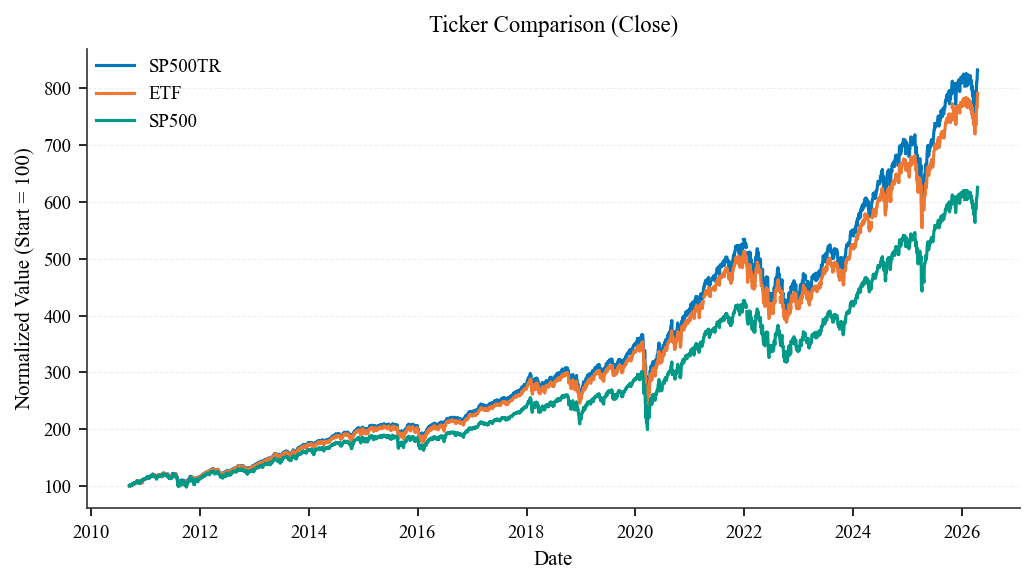

,SP500TR,ETF,SP500
Date,,,
2010-09-15,100.00000000,100.00000000,100.00000000
2010-09-16,99.98032715,100.00000000,99.96356563
2010-09-17,100.06327634,100.00000000,100.04622108
2010-09-20,101.58767217,100.00000000,101.56790382
2010-09-21,101.32926402,100.00000000,101.30748164
...,...,...,...
2026-04-10,808.69125779,768.28554794,605.90811791
2026-04-13,816.91836359,766.84112165,612.07218779
2026-04-14,826.56560106,781.49466977,619.28415258


In [16]:
plots.YahooFinance.compare_tickers({
    "SP500": SP500,
    "SP500TR": SP500TR,
    "ETF": ETF
}, col="Close", filename="11-sp500-etf-close-comparison.png")

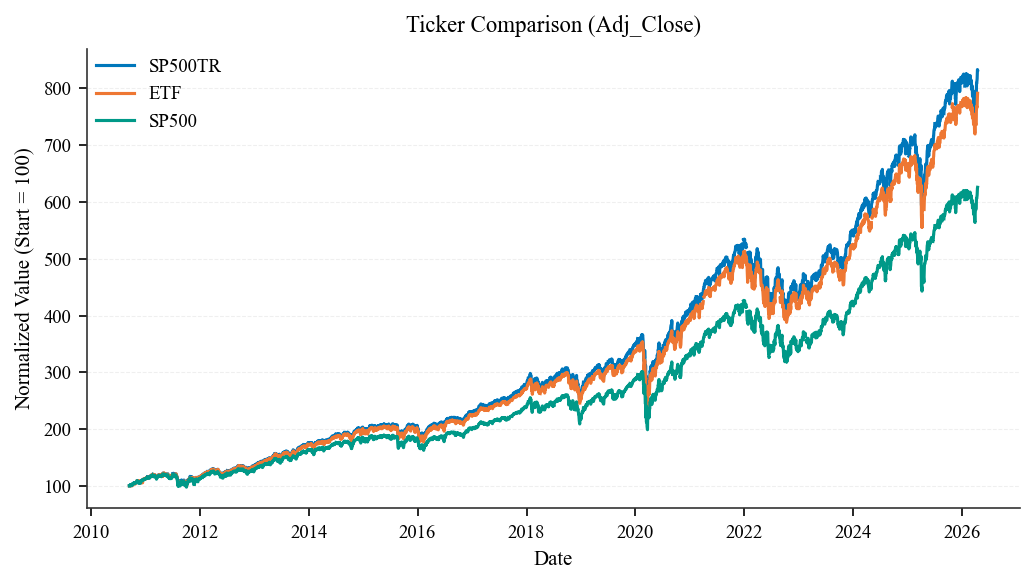

,SP500TR,ETF,SP500
Date,,,
2010-09-15,100.00000000,100.00000000,100.00000000
2010-09-16,99.98032715,100.00000000,99.96356563
2010-09-17,100.06327634,100.00000000,100.04622108
2010-09-20,101.58767217,100.00000000,101.56790382
2010-09-21,101.32926402,100.00000000,101.30748164
...,...,...,...
2026-04-10,808.69125779,768.28554794,605.90811791
2026-04-13,816.91836359,766.84112165,612.07218779
2026-04-14,826.56560106,781.49466977,619.28415258


In [17]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "SP500": SP500,
    "ETF": ETF
}, col="Adj_Close", filename="12-sp500-etf-components-10y-returns.png")

Widzimy nie tylko różnicę między indeksem uwzględniającym dywidendy a tym nieuwzględniającym, ale także między indeksem total return a odpowiadającym mu ETF-em, który zwykle osiąga nieco niższe wyniki z powodu **błędu odwzorowania** (tracking error).

#### Hybrydowy indeks S&P 500

Sam ETF nie jest więc wystarczający jako pełny benchmark historyczny, ponieważ jego najdłuższa porównywalna historia (dla ETF-u akumulującego dywidendy) rozpoczyna się dopiero około 2010 roku. Z tego powodu w analizie potrzebne są oba szeregi: **SP500TR** (długi horyzont historyczny i referencja total return) oraz **benchmark hybrydowy** (odwzorowanie realnych warunków inwestora poprzez uwzględnienie tracking error i wykorzystanie rzeczywistych notowań ETF tam, gdzie są dostępne).

W praktyce: SP500TR odpowiada za część historyczną (przed debiutem ETF), a hybryda zapewnia ciągłość serii i porównywalność wyników z realnym instrumentem inwestycyjnym.

Do konstrukcji hybrydowego indeksu rozważono podejścia oparte na **splicingu**, tj. łączeniu fragmentów szeregów czasowych w jedną spójną serię. Przyjęto, że w okresie dostępności ETF-u indeks hybrydowy odpowiada jego rzeczywistym notowaniom, natomiast wcześniejsze obserwacje są rekonstruowane na podstawie indeksu SP500TR.

Rozważono następujące podejścia:

1. **Proste skalowanie** — dane SP500TR są skalowane tak, aby ich wartość w punkcie łączenia była zgodna z wartością ETF-u.

2. **Bezwzględna różnica odwzorowania (tracking difference)** — w okresie wspólnym estymowana jest średnia różnica stóp zwrotu:

   $$\overline{\text{TD}} = \frac{1}{T}\sum_{t=1}^{T}(R_{\text{TR}} - R_{\text{ETF}}),$$

   która następnie koryguje historyczne stopy zwrotu:

   $$r_{\text{HYB}} = R_{\text{TR}} - \overline{\text{TD}}.$$

   Podejście to pomija jednak kumulatywny charakter błędu odwzorowania oraz jego proporcjonalność do poziomu cen.

3. **Względna różnica odwzorowania** — w okresie wspólnym estymowana jest relatywna różnica wyników ETF względem indeksu:

   $$
   TD_{annual} = \left(\frac{R_{\text{TR}}}{R_{\text{ETF}}}\right)^{\frac{252}{N}} - 1,
   $$

   gdzie $R_{\text{TR}}$ i $R_{\text{ETF}}$ oznaczają całkowite stopy zwrotu, a $N$ liczbę dni sesyjnych.

   Otrzymany parametr interpretowany jest jako średni roczny koszt odwzorowania i przekształcany do dziennego czynnika, który jest następnie kumulowany wstecznie:

   $$
   P^{adj}_t = \frac{P_t}{d^k}, \quad d = (1 + TD_{annual})^{1/252},
   $$

   gdzie $k$ oznacza liczbę dni od momentu rozpoczęcia notowań ETF.

   Tak skorygowana seria jest następnie skalowana w punkcie łączenia w celu zapewnienia ciągłości z rzeczywistymi notowaniami ETF.

Do utworzenia benchmarku przyjęto **trzecie podejście**, ponieważ pozwala ono uchwycić kumulatywny charakter błędu odwzorowania, przy jednoczesnym zachowaniu prostoty i stabilności estymacji oraz pełnej zgodności z obserwowanymi danymi ETF po dacie jego debiutu.

Saved benchmark to /home/michael/Documents/University/Semestr 4/Projekt indywidualny/Repo/data/processed/benchmark_2026-06-01.csv
Deleted old file: benchmark_2026-04-19.csv
Deleted 1 old file(s) for benchmark
DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 24809 entries, 1927-12-30 00:00:00+00:00 to 2026-06-01 00:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         24720 non-null  float64
 1   Open          24720 non-null  float64
 2   High          24720 non-null  float64
 3   Low           24720 non-null  float64
 4   Volume        24720 non-null  float64
 5   Adj_Close     24720 non-null  float64
 6   Dividends     24720 non-null  float64
 7   Stock_Splits  24720 non-null  float64
dtypes: float64(8)
memory usage: 1.7 MB
None


,Close,Open,High,Low,Volume,Adj_Close,Dividends,Stock_Splits
count,24720.00000000,24720.00000000,24720.00000000,24720.00000000,24720.00000000,24720.00000000,24720.00000000,24720.00000000
mean,740.90467868,740.73544497,744.98109587,736.22990171,980920802.75080907,740.90467868,0.00000000,0.00000000
std,1278.87572052,1278.56433370,1285.29971421,1271.37336244,1699364539.53659034,1278.87572052,0.00000000,0.00000000
min,4.40000010,4.40000010,4.40000010,4.40000010,0.00000000,4.40000010,0.00000000,0.00000000
25%,24.97999954,24.97999954,24.97999954,24.97999954,1610000.00000000,24.97999954,0.00000000,0.00000000
50%,103.71500015,103.70999908,104.58999634,102.87500000,22565000.00000000,103.71500015,0.00000000,0.00000000
75%,1095.64251709,1095.68502808,1102.73248291,1088.27999878,1202925000.00000000,1095.64251709,0.00000000,0.00000000
max,7612.79980469,7582.29003906,7617.66015625,7563.54980469,11456230000.00000000,7612.79980469,0.00000000,0.00000000


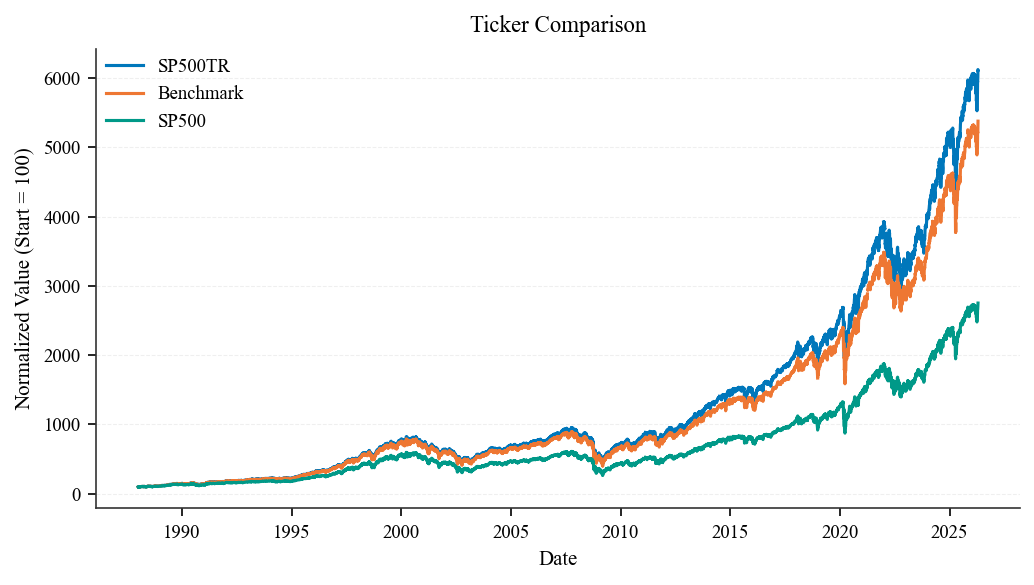

,SP500TR,Benchmark,SP500
Date,,,
1988-01-04,100.00000000,100.00000000,100.00000000
1988-01-05,101.07413488,101.07281427,101.05102853
1988-01-06,101.17569326,101.17304942,101.15261865
1988-01-07,102.02718642,102.02318730,102.00437791
1988-01-08,95.12929205,95.12432042,95.10041087
...,...,...,...
2026-04-10,5940.70015447,5218.67184062,2663.47193549
2026-04-13,6001.13702479,5208.86040166,2690.56816781
2026-04-14,6072.00627755,5308.39638681,2722.27077297


In [18]:
benchmark = features.construct_hybrid(
    long_df=SP500TR,
    short_df=ETF,
    save_csv=True,
    cleanup_old=True
)

plots.summarize_df(SP500)

plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    # "ETF": ETF, # here shows only after 2010-09-14
    "SP500": SP500
}, hide_col=True, filename="13-sp500-benchmark-comparison.png")

Poniżej przedstawiono wizualizację dwóch okresów hybrydowego indeksu:  
- **przed debiutem ETF** – historyczne notowania odtworzone na podstawie SP500TR z uwzględnieniem tracking difference.  
- **po debiucie ETF** – hybrydowy indeks pokrywa się z ETF-em.

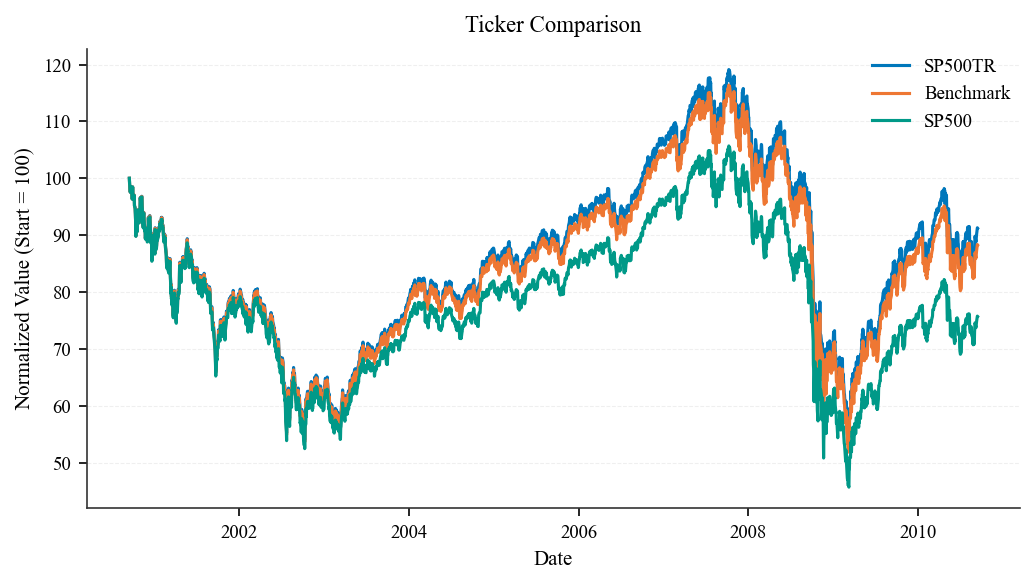

,SP500TR,Benchmark,SP500
Date,,,
2000-09-14,100.00000000,100.00000000,100.00000000
2000-09-15,98.98306332,98.98177003,98.98303453
2000-09-18,97.54650677,97.54395776,97.54468755
2000-09-19,98.58632187,98.58245762,98.58394250
2000-09-20,98.01042757,98.00530536,98.00589995
...,...,...,...
2010-09-08,89.38764760,86.50484576,74.20435276
2010-09-09,89.81993082,86.92205189,74.56292972
2010-09-10,90.25854274,87.34537154,74.92555407


In [19]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    "SP500": SP500
    },
    hide_col=True,
    start_date="2000-09-14",
    end_date="2010-09-14",
    filename="14-sp500-benchmark-2000-2010.png"
)

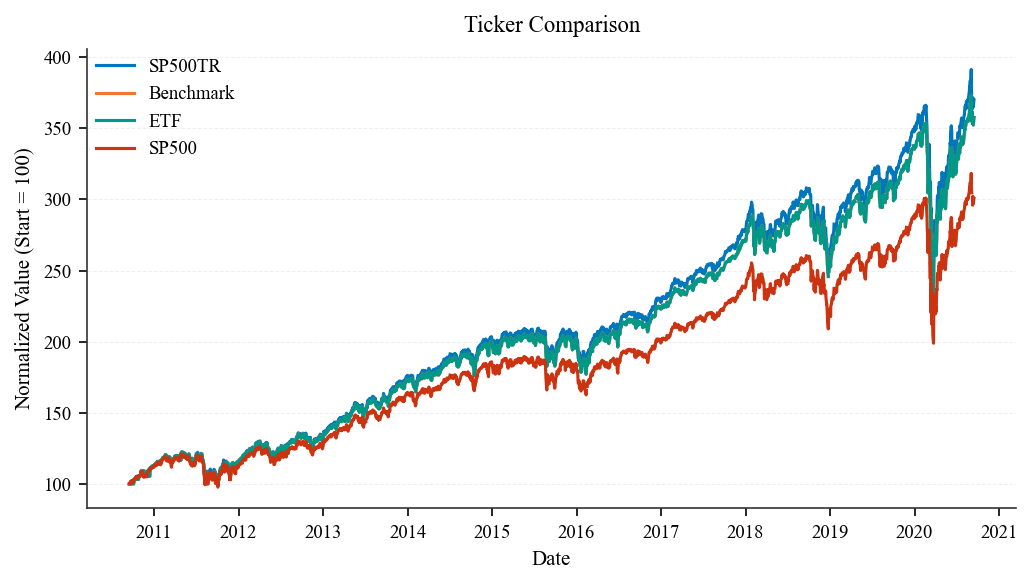

,SP500TR,Benchmark,ETF,SP500
Date,,,,
2010-09-15,100.00000000,100.00000000,100.00000000,100.00000000
2010-09-16,99.98032715,100.00000000,100.00000000,99.96356563
2010-09-17,100.06327634,100.00000000,100.00000000,100.04622108
2010-09-20,101.58767217,100.00000000,100.00000000,101.56790382
2010-09-21,101.32926402,100.00000000,100.00000000,101.30748164
...,...,...,...,...
2020-09-08,364.13432784,353.10862688,353.10862688,296.14515070
2020-09-09,371.48993491,357.72449837,357.72449837,302.11099071
2020-09-10,364.97495752,357.89197132,357.89197132,296.79843039


In [20]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    "ETF": ETF,
    "SP500": SP500
    },
    hide_col=True,
    start_date="2010-09-14",
    end_date="2020-09-14",
    filename="15-sp500-etf-benchmark-2010-2020.png"
)

#### S&P 500 Equal Weighted

Dla indeksu S&P 500 Equal Weighted dostępne są następujące tickery:

- **SP500EW (^SP500EW, S&P 500 Equal Weight Index)** – indeks cenowy (*price return*) równoważonej wersji S&P 500, gdzie każda spółka ma identyczny udział niezależnie od kapitalizacji
- **ETF_EW (RSP, Invesco S&P 500 Equal Weight ETF)** – fundusz ETF replikujący indeks S&P 500 z równymi wagami, akumulujący dywidendy

Na wykresie widać, że w ostatnich latach benchmark oparty na S&P 500 przewyższał ETF na S&P 500 Equal Weight. Jednak w latach przed 2018 strategia równych wag często osiągała podobne lub lepsze wyniki. Oznacza to, że relatywna efektywność podejścia equal-weight w dużej mierze zależy od siły największych spółek w indeksie.

DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 24809 entries, 1927-12-30 00:00:00+00:00 to 2026-06-01 00:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         4884 non-null   float64
 1   Open          4884 non-null   float64
 2   High          4884 non-null   float64
 3   Low           4884 non-null   float64
 4   Volume        4884 non-null   float64
 5   Adj_Close     4884 non-null   float64
 6   Dividends     4884 non-null   float64
 7   Stock_Splits  4884 non-null   float64
dtypes: float64(8)
memory usage: 1.7 MB
None


,Close,Open,High,Low,Volume,Adj_Close,Dividends,Stock_Splits
count,4884.00000000,4884.00000000,4884.00000000,4884.00000000,4884.00000000,4884.00000000,4884.00000000,4884.00000000
mean,3834.89188473,3833.54634770,3857.53737120,3809.06421171,0.77805078,3834.89188473,0.00000000,0.00000000
std,1949.47169667,1948.51633502,1959.07737674,1938.94887621,54.37456167,1949.47169667,0.00000000,0.00000000
min,824.01000977,824.01000977,849.15997314,810.59997559,0.00000000,824.01000977,0.00000000,0.00000000
25%,2030.03002930,2029.27749634,2039.71499634,2016.26748657,0.00000000,2030.03002930,0.00000000,0.00000000
50%,3353.53002930,3351.90502930,3369.96496582,3338.53002930,0.00000000,3353.53002930,0.00000000,0.00000000
75%,5670.83020020,5668.93005371,5709.26513672,5618.32751465,0.00000000,5670.83020020,0.00000000,0.00000000
max,8465.96972656,8442.40039062,8478.80957031,8422.82031250,3800.00000000,8465.96972656,0.00000000,0.00000000


DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 24809 entries, 1927-12-30 00:00:00+00:00 to 2026-06-01 00:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         5777 non-null   float64
 1   Open          5777 non-null   float64
 2   High          5777 non-null   float64
 3   Low           5777 non-null   float64
 4   Volume        5777 non-null   float64
 5   Adj_Close     5777 non-null   float64
 6   Dividends     5778 non-null   float64
 7   Stock_Splits  5778 non-null   float64
dtypes: float64(8)
memory usage: 1.7 MB
None


,Close,Open,High,Low,Volume,Adj_Close,Dividends,Stock_Splits
count,5777.00000000,5777.00000000,5777.00000000,5777.00000000,5777.00000000,5777.00000000,5778.00000000,5778.00000000
mean,85.11769649,85.11569804,85.58323521,84.58833569,2083766.52189718,74.84854388,0.00540412,0.00069228
std,48.09390365,48.08812447,48.32767153,47.84429266,3724193.27455876,49.64361500,0.05079279,0.05262247
min,20.59000015,20.59000015,21.15999985,18.00000000,4400.00000000,15.51315212,0.00000000,0.00000000
25%,43.75999832,43.79999924,44.07249832,43.48749924,398000.00000000,32.69854736,0.00000000,0.00000000
50%,75.73000336,75.66999817,76.05999756,75.16000366,782400.00000000,62.63351822,0.00000000,0.00000000
75%,112.08000183,112.12999725,112.69000244,111.41000366,1987600.00000000,101.09176636,0.00000000,0.00000000
max,204.97000122,204.27000427,205.24000549,203.17999268,57508500.00000000,204.09623718,0.83100000,4.00000000


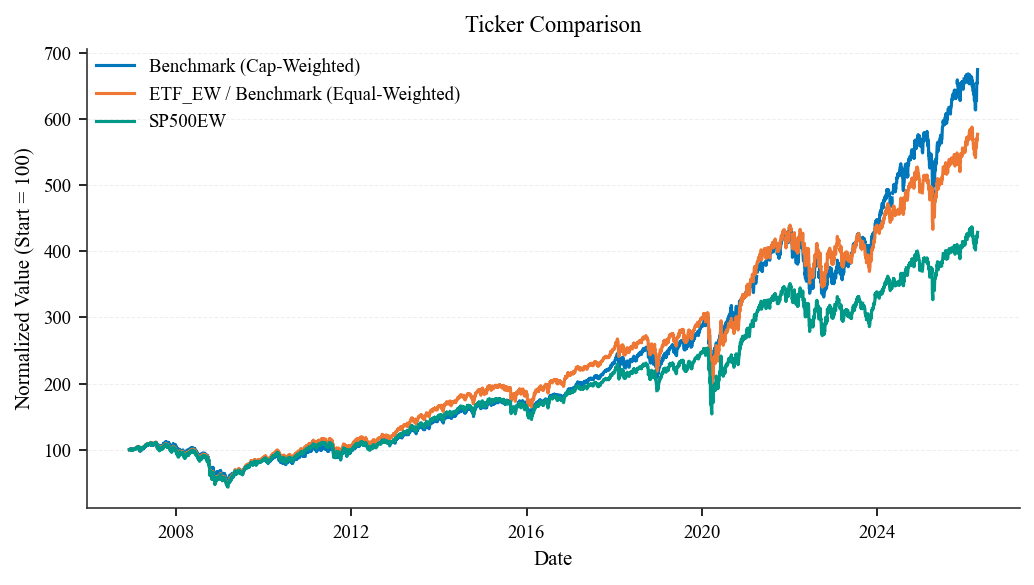

,Benchmark (Cap-Weighted),ETF_EW / Benchmark (Equal-Weighted),SP500EW
Date,,,
2006-12-08,100.00000000,100.00000000,100.00000000
2006-12-11,100.22717162,100.04207389,100.08383243
2006-12-12,100.12360155,99.89505153,99.87873422
2006-12-13,100.25771679,100.06300644,99.92091110
2006-12-14,101.13482585,100.79785448,100.74660099
...,...,...,...
2026-04-10,655.10760898,566.44938931,420.13602801
2026-04-13,653.87596450,572.72889199,424.98840989
2026-04-14,666.37086421,575.11970839,426.64822117


In [21]:
SP500EW = dataset.YahooFinance.load_ticker(tickers[3])
ETF_EW = dataset.YahooFinance.load_ticker(tickers[4])

plots.summarize_df(SP500EW)
plots.summarize_df(ETF_EW)

plots.YahooFinance.compare_tickers({
    "Benchmark (Cap-Weighted)": benchmark,
    "ETF_EW / Benchmark (Equal-Weighted)": ETF_EW,
    "SP500EW": SP500EW,
}, hide_col=True, filename="16-sp500-equal-weighted-comparison.png")

Analogicznie do hybrydowego benchmarku dla S&P 500 ważonego kapitalizacją, można byłoby
skonstruować benchmark hybrydowy dla wersji equal-weighted, uwzględniając wpływ dywidend
zamiast błędu odwzorowania. W tym przypadku jednak `ETF_EW` (RSP) dysponuje najdłuższą
dostępną historią — sięgającą 2003 roku — a przedłużenie jej wstecz napotyka na istotne
ograniczenia: indeks dochodowy `SP500EWTR` nie jest dostępny w serwisie Yahoo Finance,
`SP500EW` obejmuje krótszy okres, natomiast zastosowanie benchmarku cap-weighted jako
substytutu zniekształciłoby charakterystykę strategii equal-weighted. Z tego powodu
`benchmark_ew` ograniczony jest do okresu dostępności `ETF_EW`, a porównanie obu podejść
prowadzone jest na wspólnym horyzoncie czasowym.

In [22]:
benchmark_ew = SP500EW

#### Uzyskanie danych pojedyńczych spółek

In [23]:
tickers = dataset.SP500.extract_tickers(sp500_components)

dataset.YahooFinance.download(tickers)

Number of unique tickers extracted: 1194


$BHMSQ: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$BSC: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$BGEN: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$AW: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$BJS: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$BMGCA: possibly delisted; no timezone found
$BIG: possibly delisted; no timezone found
$ATGE: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01) (Yahoo error = "No data found, symbol may be delisted")
$APOL: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$AVP: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ACKH"}}}
$ACKH: possibly delisted; no timezone found
$APCC: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$AGN: possibly delisted; no t

$CPGX: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$EOP: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$CIT.A: possibly delisted; no timezone found
$DCNAQ: possibly delisted; no timezone found
$DISH: possibly delisted; no timezone found
$DALRQ: possibly delisted; no timezone found
$CGP: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$CHK: possibly delisted; no timezone found
$CRR: possibly delisted; no timezone found
$DTV: possibly delisted; no timezone found
$DNR: possibly delisted; no timezone found
$CDAY: possibly delisted; no timezone found
$DFS: possibly delisted; no timezone found
$COG: possibly delisted; no timezone found
$DAY: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01) (Yahoo error = "No data found, symbol may be delisted")
$CVH: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$CYM: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$DISCA

$IKN: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$JNY: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$FBO: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$IMNX: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$FWLT: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$GRA: possibly delisted; no timezone found
$FBF: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$GAS: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$GFS.A: possibly delisted; no timezone found
$HCR: possibly delisted; no timezone found
$FDO: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$FJ: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$GTW: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$INCLF: possibly delisted; no timezone found
$HBI: possibly delisted; no timezone found
$GPU: possibly delis

$MERQ: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$LO: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$LLX: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$MWV: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$MMC: possibly delisted; no timezone found
$LOR: possibly delisted; no timezone found
$MDP: possibly delisted; no timezone found
$MTL: possibly delisted; no timezone found
$KORS: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$NOVL: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$MEA: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$KRB: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$LUB: possibly delisted; no timezone found
$K: possibly delisted; no timezone found
$MWW: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$MEL: possibly delisted; no price data found  (1d 1927-06-

$PCP: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$PGL: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$SMS: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$SOTR: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$PET: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01) (Yahoo error = "No data found, symbol may be delisted")
$PVT: possibly delisted; no timezone found
$ODP: possibly delisted; no timezone found
$RLM: possibly delisted; no timezone found
$SK: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$RATL: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$RDS.A: possibly delisted; no timezone found
$SNV: possibly delisted; no timezone found
$RRD: possibly delisted; no timezone found
$PXD: possibly delisted; no timezone found
$STJ: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$PEL: possibly delisted; no pric

$USH: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$WWY: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$UTX: possibly delisted; no timezone found
$SYMC: possibly delisted; no timezone found
$TA: possibly delisted; no timezone found
$WLTW: possibly delisted; no timezone found
$X: possibly delisted; no timezone found
$SWY: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$TIN: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$USS: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$WIN: possibly delisted; no timezone found
$TUP: possibly delisted; no timezone found
$TSS: possibly delisted; no timezone found
$WBA: possibly delisted; no timezone found
$SWN: possibly delisted; no timezone found
$YNR: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$WFM: possibly delisted; no price data found  (1d 1927-06-26 -> 2026-06-01)
$USW: possibly delisted; no price data 

Saved Close.csv (24809 rows x 1199 columns)
Saved Open.csv (24809 rows x 1199 columns)
Saved High.csv (24809 rows x 1199 columns)
Saved Low.csv (24809 rows x 1199 columns)
Saved Volume.csv (24809 rows x 1199 columns)
Saved Adj_Close.csv (24809 rows x 1199 columns)
Saved Dividends.csv (24809 rows x 826 columns)
Saved Stock_Splits.csv (24809 rows x 826 columns)


In [24]:
yf_data: dict[str, pd.DataFrame] = dataset.YahooFinance.load()

#### Ile danych brakuje?

Na poniższym wykresie widać, że w 1996 dane z Yahoo Finance pokrywają tylko 38%. Przy wyższym pokryciu można byłoby zastosować imputację brakujących danych, jednak jest ono na tyle małe, że konieczne będzie skorzystanie z dostawców danych, pokrywających spółki, które już nie są notowane.

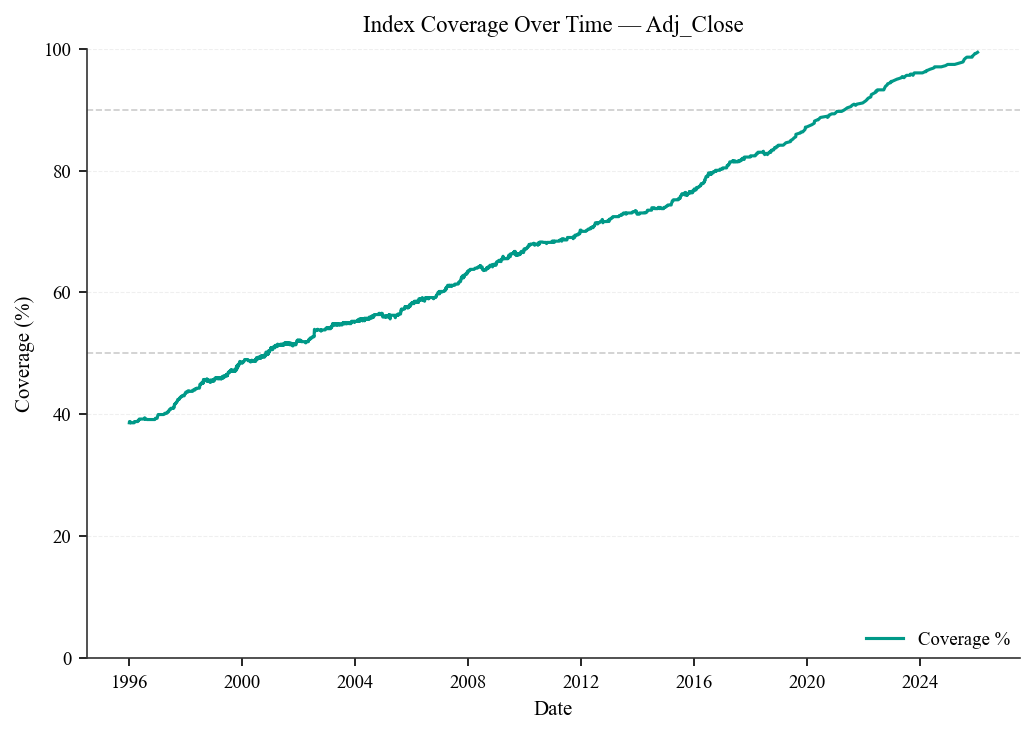

Missing ticker coverage periods:
- AABA:
  missing from 1999-12-08 to 2017-06-16
- AAL:
  missing from 1996-01-02 to 1997-01-13
- AAMRQ:
  missing from 1996-01-02 to 2003-03-10
- ABC:
  missing from 2001-08-30 to 2023-08-25
- ABI:
  missing from 1996-01-02 to 2008-11-20
- ABKFQ:
  missing from 2000-12-11 to 2008-06-10
- ABMD:
  missing from 2018-05-31 to 2022-12-19
- ABS:
  missing from 1996-01-02 to 2006-05-31
- ABX:
  missing from 1996-01-02 to 2002-07-18
- ACAS:
  missing from 2007-07-09 to 2009-03-02
- ACKH:
  missing from 1996-01-02 to 2000-11-08
- ACS:
  missing from 2004-04-02 to 2010-02-02
- ACV:
  missing from 1996-01-02 to 2006-11-16
- ADCT:
  missing from 1999-08-02 to 2007-06-26
- ADS:
  missing from 2013-12-23 to 2020-05-22
- ADT:
  missing from 2012-10-02 to 2016-04-28
- AEE:
  missing from 1996-01-02 to 1997-12-31
- AET:
  missing from 1996-01-02 to 2018-11-28
- AFS.A:
  missing from 1998-04-08 to 2000-11-29
- AGC:
  missing from 1996-01-02 to 2001-08-20
- AGN:
  missing

,available,missing,not_downloaded,total,coverage_pct
count,2705.00000000,2705.00000000,2705.00000000,2705.00000000,2705.00000000
mean,312.50055453,184.24879852,0.00000000,496.74935305,62.77348877
std,72.76614649,67.95654165,0.00000000,5.16624733,14.02972198
min,188.00000000,3.00000000,0.00000000,487.00000000,38.60369610
25%,255.00000000,133.00000000,0.00000000,494.00000000,51.51515152
50%,313.00000000,184.00000000,0.00000000,497.00000000,62.97786720
75%,364.00000000,240.00000000,0.00000000,499.00000000,73.23943662
max,500.00000000,299.00000000,0.00000000,507.00000000,99.40357853


,available,missing,not_downloaded,total,coverage_pct
1996-01-02,188,299,0,487,38.60369610
1996-01-03,189,298,0,487,38.80903491
2025-12-22,499,4,0,503,99.20477137
2026-01-14,500,3,0,503,99.40357853


In [26]:
coverage_df = plots.coverage_over_time(
    price_data=yf_data,
    components=sp500_components,
    filename="17-yf-coverage-over-time.png",
)

plots.summarize_df(coverage_df)

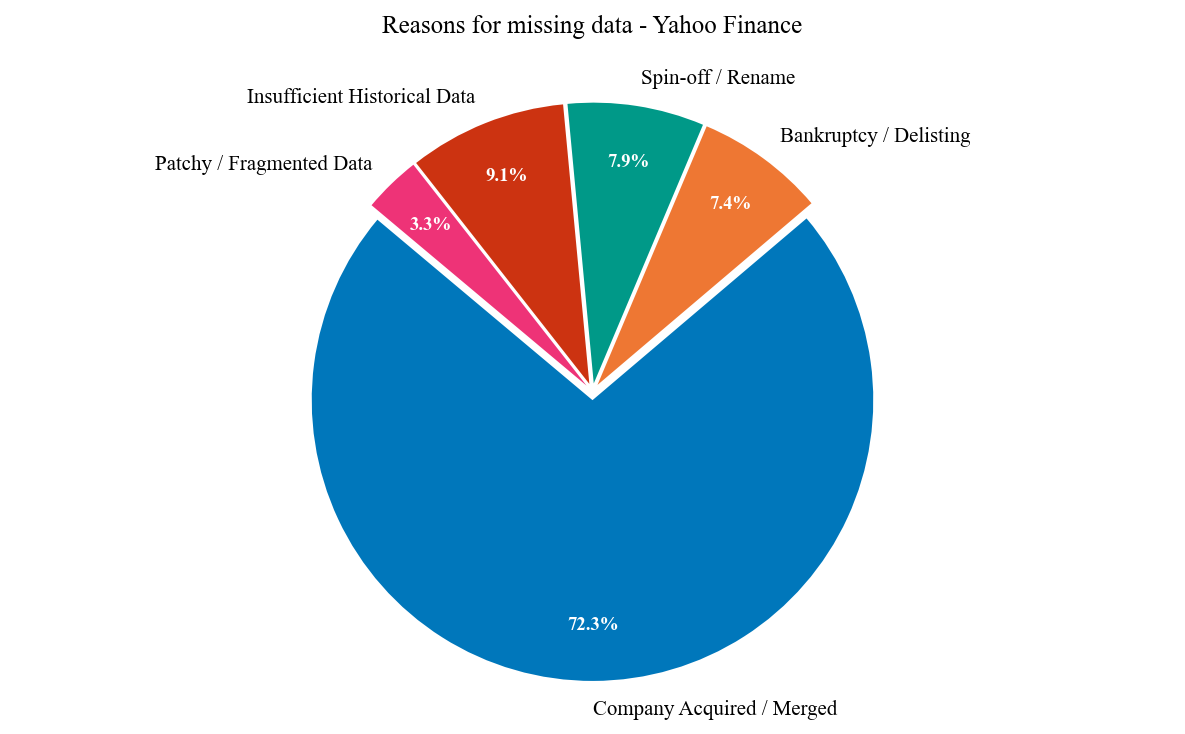

In [27]:
plots.plot_missing_data_reasons("Yahoo Finance", filename="18-yf-missing-data-reasons.png")